<a href="https://colab.research.google.com/github/wlrjs1300-coder/AI_26/blob/main/07_02_%EC%8B%AC%EC%B8%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D(%EB%94%A5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

# (재현성 고정) 매번 실행할 때 결과가 비슷하게 나오도록 "랜덤"을 같은 출발점(42)으로 맞춤
# 예: 주사위를 던지기 전에 항상 같은 방식으로 흔들어 놓는 느낌
tf.keras.utils.set_random_seed(42)

# (결정적 계산) GPU/병렬처리 등으로 인해 결과가 미세하게 달라질 수 있는데,
# 가능한 한 같은 계산 경로를 타도록 설정해서 결과 흔들림을 줄임
tf.config.experimental.enable_op_determinism()

from tensorflow import keras

# (데이터 불러오기) 패션 MNIST: 28x28 흑백 이미지와 정답(0~9 라벨)로 구성된 의류 분류 데이터셋
# load_data()는 (훈련용 데이터, 훈련 정답), (테스트용 데이터, 테스트 정답) 형태로 돌려줌
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# train_input : 훈련 이미지들 (보통 60000장, 각 28x28)
# train_target: 훈련 정답 라벨들 (0~9)
# test_input  : 테스트 이미지들 (보통 10000장, 각 28x28)
# test_target : 테스트 정답 라벨들 (0~9)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
from sklearn.model_selection import train_test_split

# (정규화) 이미지 픽셀 값은 원래 0~255 범위
# 신경망이 학습하기 쉽도록 255로 나누어 0~1 사이 값으로 변환
# 예: 255 → 1.0 / 128 → 약 0.5
train_scaled = train_input / 255.0


# (이미지 펼치기)
# 원래 이미지 형태 : 28 x 28 (2차원)
# 신경망 입력에 사용하기 위해 784개의 숫자를 가진 1차원 벡터로 펼침
# -1 은 "이미지 개수는 자동으로 계산해라" 라는 의미
train_scaled = train_scaled.reshape(-1, 28*28)


# (데이터 분할)
# 전체 훈련 데이터를
#  - 실제 학습에 사용하는 train 세트
#  - 모델 성능을 중간 점검하는 validation 세트
# 로 나눔
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled,        # 입력 데이터
    train_target,        # 정답 라벨
    test_size=0.2,       # 전체의 20%를 검증 데이터로 사용
    random_state=42      # 실행할 때마다 같은 방식으로 섞이도록 고정
)

In [3]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [4]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [5]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


In [ ]:
# 인공신경망 모델에 새로운 층(layer)을 추가하려고 한다.

# 기본적인 신경망 구조
# 입력층(Input Layer) → 은닉층(Hidden Layer) → 출력층(Output Layer)

# 이전에 만든 모델과 다른 점은
# 입력층과 출력층 사이에 "밀집층(Dense Layer)"을 하나 더 추가한 것이다.
# 이 중간 층을 "은닉층(Hidden Layer)"이라고 부른다.


# 은닉층에는 활성화 함수(activation function)가 적용된다.
# 활성화 함수는 뉴런에서 계산된 선형 결과값을 변형하는 함수이다.

# 예: 뉴런이 계산한 값
# z = a*4 + b*2
# 이런 계산은 단순한 선형 계산이다.


# 출력층의 활성화 함수는 문제 종류에 따라 제한된다.
# 이진 분류  → sigmoid 함수
# 다중 분류  → softmax 함수


# 하지만 은닉층의 활성화 함수는 비교적 자유롭게 선택할 수 있다.
# 대표적으로 사용하는 함수
# - sigmoid
# - ReLU


# 만약 은닉층이 선형 계산만 수행한다면 의미가 거의 없다.
# 예를 들어

# a*4 + 2*b
# b*3 - 5 = c

# 이런 구조라면 결국 하나의 식으로 합쳐질 수 있다.
# a*12 + 1 = c

# 즉, 중간 과정이 있어도 결국 하나의 선형 계산과 동일해진다.


# 그래서 은닉층에서는 활성화 함수를 사용해
# 계산 결과를 "비선형적으로 변형"해야 한다.

# 예를 들어

# a*4 + 2*b
# log(b) = k
# k*3 - 5 = c

# 여기서 log(b) = k 가 하는 역할은
# 선형 계산 결과를 비선형 함수로 변형하여
# 다음 층에서 새로운 패턴을 학습할 수 있게 만드는 것이다.

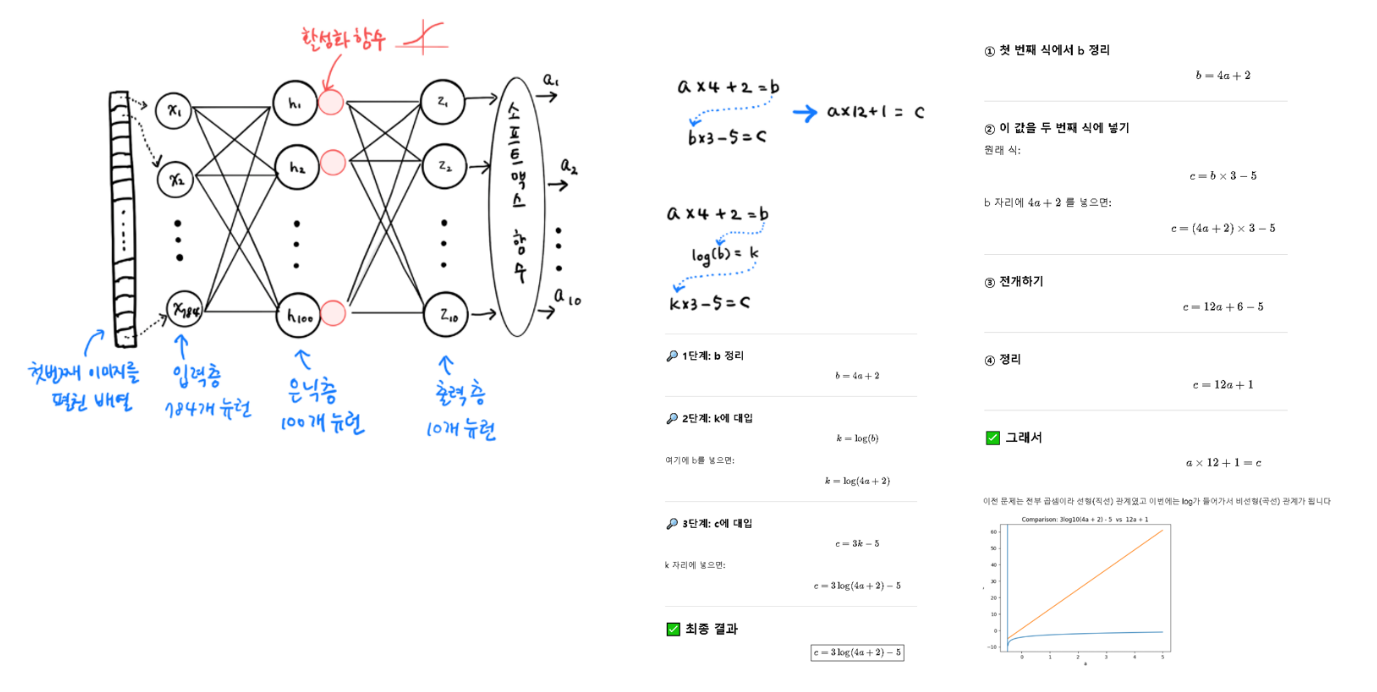

In [6]:
# Dense(밀집층) 레이어를 사용해 신경망의 층을 만든다.

# -----------------------
# 은닉층 (Hidden Layer)
# -----------------------

# Dense(100) : 뉴런 100개를 가진 층 생성
# activation='sigmoid' : 각 뉴런의 계산 결과에 시그모이드 활성화 함수 적용
# input_shape=(784,) : 입력 데이터의 크기 (28x28 이미지를 펼친 784개 값)

dense1 = keras.layers.Dense(
    100,                    # 은닉층의 뉴런 개수
    activation='sigmoid',   # 활성화 함수 (비선형 변환 역할)
    input_shape=(784,)      # 입력 데이터 크기
)

# 이 은닉층의 역할
# 784개의 입력값(픽셀)을 받아서
# 중요한 특징을 추출한 뒤
# 100개의 새로운 값(특징)으로 변환


# -----------------------
# 출력층 (Output Layer)
# -----------------------

# Dense(10) : 뉴런 10개
# 패션 MNIST는 10개의 클래스(옷 종류)를 분류해야 하기 때문
# activation='softmax' : 각 클래스에 속할 확률을 계산

dense2 = keras.layers.Dense(
    10,                 # 분류할 클래스 개수
    activation='softmax'
)

# 출력층의 역할
# 은닉층에서 전달된 100개의 특징을 이용하여
# 각 클래스(0~9)에 속할 확률을 계산

# softmax 함수는
# 모든 출력값을 0~1 사이 확률로 변환하고
# 전체 합이 1이 되도록 만든다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# -----------------------------
# 심층 신경망 모델 생성
# -----------------------------

# Sequential 모델은 레이어를 "순서대로" 연결하는 신경망 구조이다.
# 데이터가 앞 레이어 → 다음 레이어 → 다음 레이어 순서로 통과한다.

model = keras.Sequential([dense1, dense2])

# 위에서 만든 두 개의 레이어를 순차적으로 연결
# dense1 : 은닉층 (특징 추출)
# dense2 : 출력층 (최종 분류 결과 계산)

# 리스트 형태로 레이어를 전달하면
# Sequential 모델이 자동으로 순서대로 연결해 준다.


# 데이터 흐름
# 입력 데이터 (784개 픽셀)
#        ↓
# dense1 (은닉층, 100개 뉴런, sigmoid)
#        ↓
# dense2 (출력층, 10개 뉴런, softmax)
#        ↓
# 10개의 클래스 확률 출력


# 신경망이 강력한 이유는
# 여러 층을 거치면서 데이터를 점점 더 의미 있는 특징으로 변환하기 때문이다.

# 즉
# 입력 데이터 → 특징 추출 → 더 복잡한 특징 → 최종 분류

# Sequential 모델에서는
# 2개 이상의 층을 자유롭게 추가하여 더 깊은(deep) 신경망을 만들 수 있다.

In [8]:
model.summary() # 층에 대한 유용한 정보가 나옴

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# model.summary()를 실행하면 모델의 전체 구조가 출력된다.

# 출력되는 정보
# 1) 모델 이름
# 2) 각 층(layer)의 정보
# 3) 출력 데이터 크기
# 4) 학습해야 하는 파라미터 개수


# -----------------------------
# 층 정보
# -----------------------------

# 출력에는 다음 정보가 표시된다.

# 층 이름(클래스 이름)
# 출력 크기(Output Shape)
# 파라미터 개수(Param #)

# 만약 층 이름을 직접 지정하지 않으면
# 케라스가 자동으로 Dense, Dense_1 같은 이름을 붙여준다.


# -----------------------------
# 출력 크기(Output Shape)
# -----------------------------

# 예: (None, 100)

# None → 아직 정해지지 않은 샘플 개수
# 100  → 해당 층의 뉴런 개수

# 즉,
# 입력 데이터가 들어오면
# 각 샘플마다 100개의 출력값이 만들어진다는 의미


# -----------------------------
# 왜 None 이 사용될까?
# -----------------------------

# 케라스는 학습할 때 데이터를 한 번에 모두 사용하지 않는다.
# 데이터를 작은 묶음(batch)으로 나누어 여러 번 학습한다.
# 이것을 "미니배치 경사 하강법"이라고 한다.

# 기본 배치 크기
# batch_size = 32

# 예
# 한번에 32개의 이미지를 사용해 학습
# 다음 32개로 또 학습
# 이런 식으로 반복한다.

# 그래서 입력 샘플 개수를 고정하지 않고
# 어떤 배치 크기에도 대응할 수 있도록
# 첫 번째 차원을 None으로 둔다.

# 신경망에서
# 배열의 첫 번째 차원을 "배치 차원(batch dimension)"이라고 부른다.


# -----------------------------
# 파라미터 개수 계산
# -----------------------------

# 은닉층 예시
# 입력 : 784
# 뉴런 : 100

# 계산
# 가중치(weight) : 784 * 100
# 절편(bias)     : 100

# 총 파라미터 수
# 784 * 100 + 100 = 78,500


# 정리 공식

# 파라미터 수 =
# (입력 개수 × 출력 뉴런 개수) + 출력 뉴런 개수(bias)

In [ ]:
# -----------------------------
# Non-trainable params
# -----------------------------

# Non-trainable params: 0

# 의미
# 학습 과정에서 업데이트되지 않는 파라미터 수

# 보통 신경망에서는
# 가중치(weight)와 bias는
# 경사 하강법(gradient descent)으로 학습된다.

# 하지만 일부 층에서는
# 학습되지 않는 파라미터가 존재할 수 있다.

# 예
# - BatchNormalization의 이동 평균
# - 미리 고정된 가중치
# - 동결된(pretrained) 레이어

# 현재 모델에서는
# 학습되지 않는 파라미터가 없기 때문에
# 0으로 표시된다.

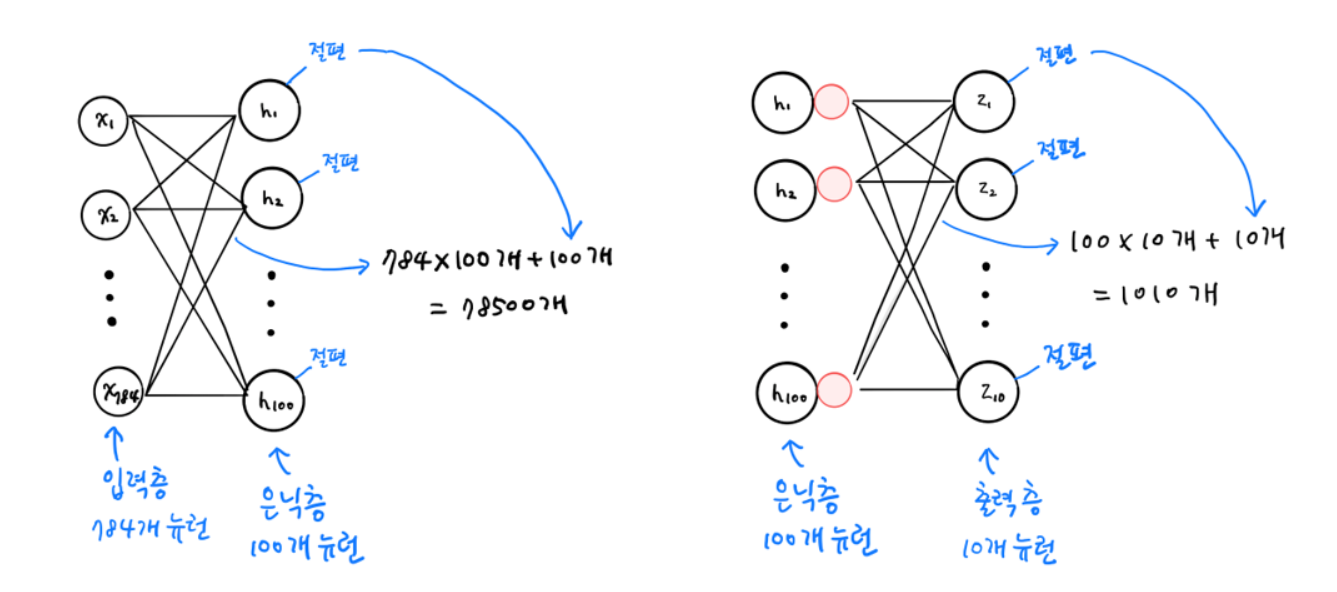

In [10]:
# -----------------------------
# Sequential 모델 생성 방법
# -----------------------------

# Sequential 클래스는 신경망의 층을 "순서대로" 연결하는 모델이다.
# 이전에는 Dense 층을 따로 변수(dense1, dense2)에 저장했지만
# 실제로는 따로 사용할 일이 없는 경우가 많다.

# 그래서 아래처럼 Sequential 생성자 안에서
# Dense 객체를 바로 만들어 사용하는 경우가 많다.

model = keras.Sequential([

    # -----------------------------
    # 은닉층 (Hidden Layer)
    # -----------------------------

    keras.layers.Dense(
        100,                     # 뉴런 개수
        activation='sigmoid',    # 활성화 함수
        input_shape=(784,),      # 입력 데이터 크기 (28×28 이미지를 펼친 784)
        name='hidden'            # 레이어 이름 지정 (영문 사용 권장)
    ),

    # -----------------------------
    # 출력층 (Output Layer)
    # -----------------------------

    keras.layers.Dense(
        10,                      # 분류할 클래스 개수
        activation='softmax',    # 다중 분류에 사용하는 활성화 함수
        name='output'            # 출력층 이름
    )

], name='패션 MNIST 모델')      # 모델 전체 이름 지정


# -----------------------------
# 모델 구조 확인
# -----------------------------

# summary()를 실행하면 다음 정보가 출력된다.
# - 모델 이름
# - 각 층의 구조
# - 출력 데이터 크기
# - 학습해야 할 파라미터 개수

model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# -----------------------------
# Sequential 모델 생성
# -----------------------------

# Sequential은 층을 순서대로 쌓아 만드는 신경망 모델이다.
# 먼저 빈 모델을 하나 만든다.
model = keras.Sequential()


# -----------------------------
# 은닉층 추가
# -----------------------------

# .add() 메서드를 사용하면 모델에 새로운 층을 하나씩 추가할 수 있다.

model.add(
    keras.layers.Dense(
        100,                    # 은닉층의 뉴런 개수
        activation='sigmoid',   # 활성화 함수
        input_shape=(784,)      # 입력 데이터 크기 (28×28 이미지를 펼친 784)
    )
)

# 이 층의 역할
# 784개의 입력 데이터를 받아서
# 100개의 새로운 특징(feature)으로 변환한다.


# -----------------------------
# 출력층 추가
# -----------------------------

model.add(
    keras.layers.Dense(
        10,                     # 분류할 클래스 개수 (패션 MNIST는 10개)
        activation='softmax'    # 다중 분류에서 사용하는 활성화 함수
    )
)

# 이 층은 은닉층의 결과를 받아서
# 10개의 클래스 확률을 계산한다.


# -----------------------------
# 모델 구조 출력
# -----------------------------

# summary()를 사용하면
# - 각 층의 구조
# - 출력 크기
# - 파라미터 개수
# 등을 확인할 수 있다.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# -----------------------------
# 모델 학습 준비 (컴파일)
# -----------------------------

# compile()은 모델을 학습할 준비를 하는 단계이다.
# 여기서 손실 함수(loss)와 평가 지표(metrics)를 설정한다.

model.compile(
    loss='sparse_categorical_crossentropy',  # 다중 분류 문제에서 사용하는 손실 함수
    metrics=['accuracy']                     # 학습 중 정확도를 함께 출력
)

# sparse_categorical_crossentropy를 사용하는 이유
# 현재 정답 데이터(train_target)가 원-핫 인코딩이 아닌
# 정수 라벨 형태(0~9)이기 때문이다.


# -----------------------------
# 모델 학습 시작
# -----------------------------

model.fit(
    train_scaled,   # 훈련 입력 데이터 (이미지 픽셀 값)
    train_target,   # 정답 라벨 (0~9)
    epochs=5        # 전체 데이터를 5번 반복 학습
)

# fit()은 모델을 실제로 학습시키는 함수이다.
# 훈련 데이터를 사용하여 가중치(weight)와 bias를 업데이트한다.


# -----------------------------
# 학습 결과 예시
# -----------------------------

# 처음 학습 정확도 : 약 75.25%
# 5번 반복 학습 후 : 약 87.59%

# 즉, 모델이 데이터를 반복 학습하면서
# 점점 더 정확하게 분류하도록 개선된 것이다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7525 - loss: 0.7720
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8463 - loss: 0.4270
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8604 - loss: 0.3857
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8696 - loss: 0.3600
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8759 - loss: 0.3410


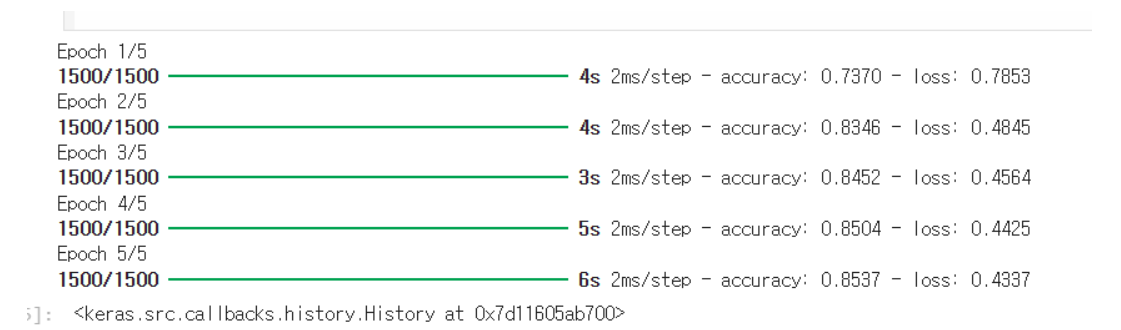

In [13]:
# -----------------------------
# 모델 성능 비교
# -----------------------------

# 은닉층이 1개인 모델
# 훈련 정확도 약 85.37%

# 은닉층을 하나 더 추가한 모델 (총 2개의 층)
# 훈련 정확도 약 87.40%

# 즉, 층을 추가하면서 모델이 더 복잡한 패턴을 학습할 수 있게 되어
# 훈련 데이터에 대한 분류 성능이 향상되었다.


# -----------------------------
# 검증 데이터 성능 확인
# -----------------------------

# evaluate()는 학습에 사용하지 않은 데이터로
# 모델의 성능을 평가하는 함수이다.

model.evaluate(val_scaled, val_target)

# val_scaled  : 검증 입력 데이터
# val_target  : 검증 정답 데이터

# 결과
# 검증 정확도 약 87.33%

# 훈련 정확도(87.40%)와 검증 정확도(87.33%)가 거의 비슷하므로
# 현재 모델은 과적합 없이 비교적 잘 학습된 상태라고 볼 수 있다.

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8733 - loss: 0.3530


[0.35684970021247864, 0.8694999814033508]

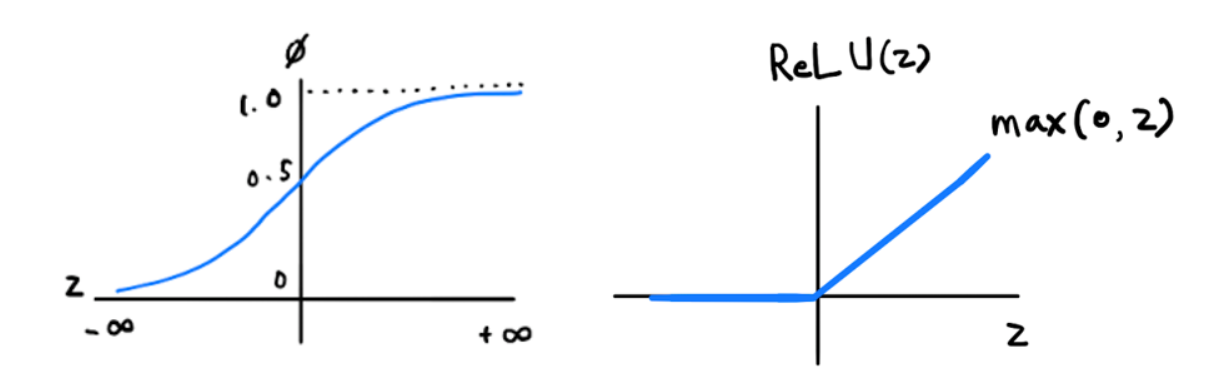

In [14]:
# -----------------------------
# 시그모이드(sigmoid) 활성화 함수
# -----------------------------

# 초기 인공신경망에서는 은닉층의 활성화 함수로
# 시그모이드(sigmoid)를 많이 사용했다.

# 하지만 시그모이드 함수는 입력값이 매우 크거나 작아질수록
# 그래프의 기울기가 거의 0에 가까워지는 문제가 있다.

# 즉, 그래프 양쪽 끝이 평평해지면서
# 가중치 업데이트가 잘 이루어지지 않는 문제가 발생한다.

# 이 현상은 층이 많은 심층 신경망(deep neural network)일수록
# 누적되어 학습을 더욱 어렵게 만든다.


# -----------------------------
# ReLU 활성화 함수
# -----------------------------

# 이러한 문제를 해결하기 위해 제안된 활성화 함수가
# ReLU(Rectified Linear Unit)이다.

# ReLU 함수 특징
# 입력값이 양수이면 그대로 출력
# 입력값이 음수이면 0을 출력

# 수식
# ReLU(z) = max(0, z)

# 즉
# z > 0  →  z 출력
# z ≤ 0  →  0 출력

# ReLU는 계산이 단순하고 기울기 소실 문제가 적어서
# 특히 이미지 처리 신경망에서 좋은 성능을 보인다.


# -----------------------------
# Flatten 층
# -----------------------------

# ReLU를 적용하기 전에
# 케라스에서 제공하는 Flatten 층을 알아둘 필요가 있다.

# Flatten 층의 역할
# 다차원 데이터를 1차원으로 펼치는 것

# 예
# 이미지 데이터
# 28 × 28

# Flatten 적용 후

# 784 (1차원 벡터)


# 중요한 점
# Flatten 층은
# 데이터를 변형만 할 뿐
# 학습되는 파라미터(가중치, bias)가 없다.

# 즉
# weight = 0
# bias   = 0


# -----------------------------
# 왜 Flatten이 필요한가?
# -----------------------------

# Dense(완전연결층)는
# 1차원 입력을 사용하기 때문이다.

# 이미지 데이터는 보통
# (28, 28) 형태이므로

# Flatten을 사용해

# (784)

# 형태로 변환한 뒤
# Dense 층에 전달한다.


# -----------------------------
# 위치
# -----------------------------

# Flatten 층은 보통
# 입력층 바로 뒤에 추가된다.

# 입력 이미지
# ↓
# Flatten
# ↓
# Dense (은닉층)
# ↓
# 출력층

In [15]:
# -----------------------------
# Sequential 모델 생성
# -----------------------------

# Sequential 모델은 층을 순서대로 쌓아 만드는 신경망 모델이다.
model = keras.Sequential()


# -----------------------------
# Flatten 층 추가
# -----------------------------

# 입력 데이터는 28×28 크기의 이미지이다.
# Dense 층은 1차원 입력을 사용하기 때문에
# Flatten을 사용하여 2차원 이미지를 1차원으로 펼친다.

model.add(keras.layers.Flatten(input_shape=(28, 28)))

# Flatten의 역할
# (28, 28) → (784)

# Flatten 층은 단순히 데이터를 펼치는 역할만 하므로
# 학습되는 파라미터(가중치, bias)가 없다.
# 따라서 model.summary()에서 파라미터 수가 0으로 표시된다.

# 출력 형태
# (None, 784)
# → 784개의 입력 값이 다음 층(은닉층)으로 전달된다는 의미


# -----------------------------
# 은닉층 추가 (ReLU 활성화 함수)
# -----------------------------

model.add(keras.layers.Dense(100, activation='relu'))

# Dense(100)
# → 뉴런 100개를 가진 완전 연결층

# ReLU 활성화 함수
# ReLU(z) = max(0, z)

# 특징
# 입력값이 양수 → 그대로 통과
# 입력값이 음수 → 0으로 출력

# ReLU는 계산이 단순하고
# 특히 이미지 처리 신경망에서 좋은 성능을 보인다.


# -----------------------------
# 출력층 추가 (Softmax)
# -----------------------------

model.add(keras.layers.Dense(10, activation='softmax'))

# Dense(10)
# → 10개의 클래스 확률을 출력

# softmax 함수
# 출력값을 0~1 사이 확률로 변환하고
# 모든 확률의 합이 1이 되도록 만든다.

# 예
# [0.01, 0.02, 0.80, 0.05 ...]


# -----------------------------
# 모델 구조 확인
# -----------------------------

# summary()를 사용하면
# - 각 층 구조
# - 출력 크기
# - 파라미터 개수
# 등을 확인할 수 있다.

model.summary()

# 여기까지가 딥러닝 모델 구조 생성 단계
# 이후 compile() → fit() 순서로 모델을 학습시킨다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# -----------------------------
# 패션 MNIST 데이터 불러오기
# -----------------------------
# (train_input, train_target) : 훈련 이미지/정답
# (test_input, test_target)   : 테스트 이미지/정답
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# -----------------------------
# 입력 데이터 스케일링(정규화)
# -----------------------------
# 픽셀 값은 0~255 범위이므로 255로 나눠 0~1 범위로 변환
# 이번에는 Flatten 층을 사용할 예정이라 reshape(784)로 펼치지 않고
# 28×28 형태를 그대로 유지한다.
train_scaled = train_input / 255.0

# -----------------------------
# 훈련/검증 데이터 분리
# -----------------------------
# train_scaled와 train_target을 함께 섞은 뒤
# 20%를 검증(validation) 세트로 분리한다.
# random_state=42 : 매번 같은 방식으로 섞이도록 고정
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [17]:
print(test_input.shape, test_target.shape) # 플래튼을 사용하려고 픽셀값 조정 안함

(10000, 28, 28) (10000,)


In [18]:
print(train_scaled.shape, train_target.shape) # 플래튼을 사용하려고 픽셀값 조정 안함

(48000, 28, 28) (48000,)


In [19]:
print(val_scaled.shape, val_scaled.shape) # 플래튼을 사용하려고 픽셀값 조정 안함

(12000, 28, 28) (12000, 28, 28)


In [20]:
# -----------------------------
# 모델 학습 준비 (컴파일)
# -----------------------------
# compile()은 "학습 규칙"을 정하는 단계이다.
# - loss: 정답(정수 라벨 0~9)과 모델 예측(softmax 확률) 사이의 오차를 계산하는 방식
# - metrics: 학습 중 함께 출력할 평가 지표(여기서는 정확도)
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 모델 학습 시작 (훈련)
# -----------------------------
# fit()은 실제로 데이터를 넣고 학습하는 단계이다.
# epochs=5 : 전체 훈련 데이터를 5번 반복해서 학습한다.
model.fit(
    train_scaled,    # 정규화된 훈련 입력 데이터 (0~1 범위, 28×28 형태 또는 Flatten으로 처리)
    train_target,    # 정수 라벨 정답 (0~9)
    epochs=5
)

# 결과 해석 예시
# ReLU를 사용한 모델이 sigmoid 모델(예: 87.59%)보다 정확도가 약간 더 좋아질 수 있다.
# (학습 시간은 컴퓨터 환경/CPU·GPU/설정에 따라 달라진다)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7637 - loss: 0.6723
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8519 - loss: 0.4061
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8685 - loss: 0.3613
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8800 - loss: 0.3340
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8874 - loss: 0.3157


In [21]:
model.evaluate(val_scaled, val_target) # 검증 점수 전(87.33%)과 비교해보면 안좋음.

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8651 - loss: 0.3861


[0.38933491706848145, 0.8648333549499512]

In [22]:
# -----------------------------
# 하이퍼파라미터(hyperparameter)란?
# -----------------------------
# 모델이 학습(자동으로 업데이트)하는 값이 아니라,
# 사람이 미리 정해줘야 하는 설정값이다.

# 신경망에서 대표적인 하이퍼파라미터 예시
# - 은닉층 개수(몇 층 쌓을지)
# - 각 은닉층의 뉴런 개수
# - 활성화 함수 종류(relu, sigmoid 등)
# - 층의 종류(Dense, Conv2D 등)
# - batch_size (한 번에 학습하는 샘플 묶음 크기)
# - epochs (전체 데이터를 몇 번 반복 학습할지)
# - optimizer 종류와 학습률(learning rate)

# -----------------------------
# 옵티마이저(optimizer)란?
# -----------------------------
# 가중치와 bias를 "어떤 방식으로" 업데이트할지 정하는 알고리즘이다.
# 즉, 경사하강법을 실제로 실행하는 '업데이트 규칙'이라고 보면 된다.

# 케라스는 여러 옵티마이저를 제공하며
# 기본으로는 RMSprop을 많이 사용한다.
# (optimizer는 바꿔가며 성능을 비교할 수 있다.)

# -----------------------------
# 옵티마이저 테스트: SGD
# -----------------------------
# SGD(Stochastic Gradient Descent)는 가장 기본적인 경사하강법 계열 옵티마이저다.
# 이름에 stochastic가 들어가지만,
# 케라스에서는 보통 미니배치(batch)를 사용해 학습한다.
# (즉, 샘플 1개만 쓰는 게 아니라 batch_size만큼 묶어서 업데이트)

# 방법 1) 옵티마이저 객체를 직접 만들어 전달
sgd = keras.optimizers.SGD()  # SGD 옵티마이저 객체 생성
model.compile(
    optimizer=sgd,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 방법 2) 문자열로 전달 (케라스가 내부적으로 객체를 만들어줌)
# 아래는 위와 같은 의미다.
model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# -----------------------------
# SGD 옵티마이저 (확률적 경사 하강법)
# -----------------------------

# learning_rate : 학습률
# 가중치를 얼마나 크게 업데이트할지 결정하는 값
# 기본값은 0.01

sgd = keras.optimizers.SGD(learning_rate=0.1)
# learning_rate=0.1 → 기본값보다 더 빠르게 학습하도록 설정


# -----------------------------
# Momentum 적용
# -----------------------------

# momentum : 이전 업데이트 방향을 일부 유지하여
# 학습이 더 빠르고 안정적으로 진행되도록 도움

# 예를 들어 공을 굴린다고 생각하면
# 이전 속도를 유지하면서 더 멀리 굴러가는 효과

sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

# momentum=0.9
# → 이전 기울기의 90%를 현재 업데이트에 반영

# nesterov=True
# → 네스테로프 모멘텀(Nesterov Momentum) 사용
# 일반 모멘텀보다 한 단계 앞을 미리 계산하여
# 더 빠르게 최적점에 수렴하도록 도움


# -----------------------------
# 적응적 학습률 (Adaptive Learning Rate)
# -----------------------------

# 모델이 최적점에 가까워질수록
# 학습률을 자동으로 줄여 안정적으로 수렴하도록 하는 방식

# 장점
# 사람이 learning_rate를 세밀하게 조정할 필요가 줄어든다.


# 대표적인 적응적 학습률 옵티마이저
# - Adagrad
# - RMSprop


# -----------------------------
# Adagrad 옵티마이저
# -----------------------------

# Adagrad는 학습이 진행될수록
# 학습률을 점점 줄여가는 방식의 옵티마이저이다.

adagrad = keras.optimizers.Adagrad()

model.compile(
    optimizer=adagrad,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

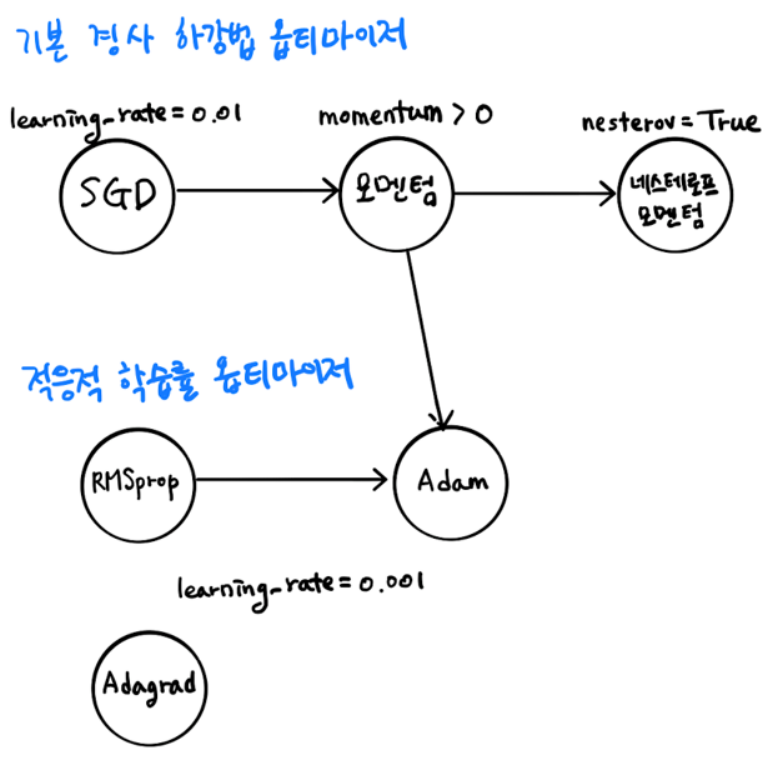

In [ ]:
# -----------------------------
# RMSprop 옵티마이저 사용
# -----------------------------

# RMSprop은 적응적 학습률(adaptive learning rate)을 사용하는 옵티마이저이다.
# 학습이 진행되면서 각 가중치에 대해 학습률을 자동으로 조정하여
# 안정적으로 최적값에 수렴하도록 도와준다.

rmsprop = keras.optimizers.RMSprop()  # RMSprop 최적화 객체 생성


# -----------------------------
# 모델 컴파일
# -----------------------------

# compile()은 모델 학습에 필요한 설정을 지정하는 단계이다.

model.compile(
    optimizer=rmsprop,                   # 가중치 업데이트 방법으로 RMSprop 사용
    loss='sparse_categorical_crossentropy',  # 정수 라벨(0~9)을 사용하는 다중 분류 손실 함수
    metrics=['accuracy']                 # 학습 과정에서 정확도(accuracy)를 함께 출력
)

In [24]:
model = keras.Sequential()  # 딥러닝의 레이어 생성
model.add(keras.layers.Flatten(input_shape=(28, 28)))   # 입력층(1차원 변환없이 사용)
model.add(keras.layers.Dense(100, activation='relu'))   # 은닉층(렐루)
model.add(keras.layers.Dense(10, activation='softmax')) # 출력층(소프트맥스)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer='adagrad', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 적응적 학습률 최적화(에이다그레드)
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5414 - loss: 1.4886
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7474 - loss: 0.7991
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7726 - loss: 0.7002
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7861 - loss: 0.6517
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7952 - loss: 0.6212


In [26]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 적응적 학습률 최적화
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7978 - loss: 0.5721
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8530 - loss: 0.4045
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8701 - loss: 0.3565
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8794 - loss: 0.3297
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3118


In [27]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# adam : 모멘텀 최적화와 RMSprop의 장점을 접목한 기법 (대부분 adam을 사용함)
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8917 - loss: 0.3008
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8996 - loss: 0.2760
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9038 - loss: 0.2610
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9056 - loss: 0.2511
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9112 - loss: 0.2385


In [28]:
model.evaluate(val_scaled, val_target) # 검증 성능 확인 88.48점!!

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8759 - loss: 0.3541


[0.3561076521873474, 0.8764166831970215]